## Algorytm centroidów w klasteryzacji (np. KMeans)


In [22]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd
import plotly.express as px

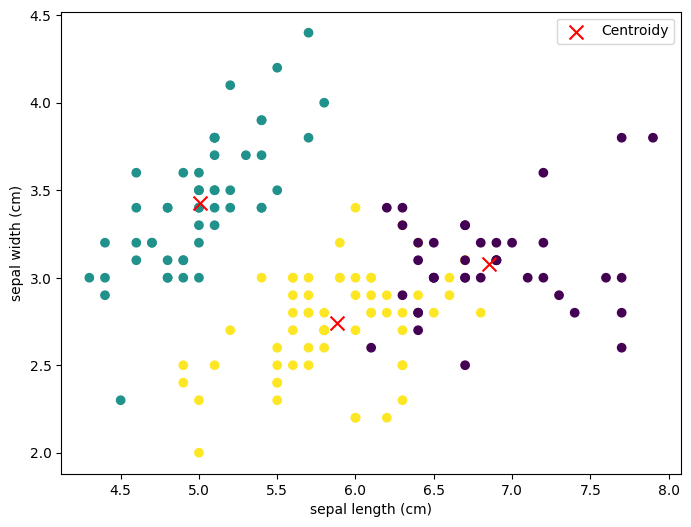

In [23]:
iris = load_iris()
X = iris.data

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

centroids = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', marker='o')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=100, label='Centroidy')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])

plt.legend()
plt.show()

In [30]:
iris = load_iris()
X = iris.data

ilosc_segmentow = 3

kmeans = KMeans(n_clusters = ilosc_segmentow, random_state=42)
kmeans.fit(X)

df = pd.DataFrame(X, columns=iris.feature_names)
df['cluster'] = kmeans.labels_

centroidy = pd.DataFrame(kmeans.cluster_centers_, columns=iris.feature_names)
centroidy['cluster'] = ['Centroid'] * ilosc_segmentow

df = pd.concat([df, centroidy], ignore_index=True)

fig = px.scatter_3d(df, x=iris.feature_names[0], y=iris.feature_names[1], z=iris.feature_names[2],
                    color='cluster', symbol='cluster', symbol_map= {'Centroid': 'x', 0: 'circle', 1: 'circle', 2: 'circle'}, 
                    opacity=0.7, color_discrete_map={'Centroid': 'red', 0: 'blue', 1: 'green', 2: 'orange'},
                    height=600, width=800)
fig.show()